In [ ]:
import json

import gc_utils
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from scipy.interpolate import interp1d

In [199]:
sim = "m12i"
# snap = 172  # z=2
# snap = 382  # z=0.5
# snap = 600  # z=0

snap = 214  # before orbit boundary
# snap = 294  # before orbit boundary
# snap = 332  # after orbit boundary
# snap = 382  # more after boundary
# snap = 486  # more after boundary

sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

species = ["star", "dark", "gas"]

In [147]:
halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:39<00:00, 39.97s/it]


In [200]:
halo_tid_z0 = sim_data[sim]["halo"]
halo_tid = gc_utils.get_halo_prog_at_snap(halt, halo_tid_z0, snap)

halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]
r_50 = halt["star.radius.50"][halo_tidx]

In [201]:
halo_pxyz = halt["position"][halo_tidx]
halo_vxyz = halt["velocity"][halo_tidx]

In [202]:
part = gc_utils.open_snapshot(snap, fire_dir, species)

Retrieving Snapshot 214..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:48<00:00, 48.99s/it]


In [203]:
r_lim = 12.8  # kpc
# r_lim = 5  # kpc
part_dict = {spec: {"pxyz": None, "vxyz": None, "mass": None} for spec in species}

for spec in species:
    msk = (
        ut.particle.get_distances_wrt_center(
            part,
            species=spec,
            center_position=halo_pxyz,
            rotation=None,
            coordinate_system="cartesian",
            total_distance=True,
        )
        < r_lim
    )

    part_dict[spec]["pxyz"] = ut.particle.get_distances_wrt_center(
        part,
        species=[spec],
        center_position=halo_pxyz,
        rotation=None,
        coordinate_system="cartesian",
        total_distance=False,
    )[msk]

    part_dict[spec]["vxyz"] = ut.particle.get_velocities_wrt_center(
        part,
        species=[spec],
        center_position=halo_pxyz,
        center_velocity=halo_vxyz,
        rotation=None,
        coordinate_system="cartesian",
        total_velocity=False,
    )[msk]

    part_dict[spec]["mass"] = part[spec]["mass"][msk]

In [208]:
G = 4.302e-6  # kpc km^2 / s^2 Msun

# ============================================================
# 1) BUILD SMOOTH RADIAL MASS PROFILE (ALL SPECIES)
# ============================================================

# concatenate all particles
pxyz_all = np.vstack([part_dict[s]["pxyz"] for s in part_dict])
mass_all = np.concatenate([part_dict[s]["mass"] for s in part_dict])

r_all = np.linalg.norm(pxyz_all, axis=1)

# logarithmic radial bins (robust)
bins = np.logspace(-3, 2, 200)  # kpc

r_cent = 0.5 * (bins[1:] + bins[:-1])
M_shell = np.zeros(len(r_cent))

# bin the mass
for i in range(len(bins) - 1):
    in_bin = (r_all >= bins[i]) & (r_all < bins[i + 1])
    M_shell[i] = np.sum(mass_all[in_bin])

# cumulative enclosed mass
M_enc = np.cumsum(M_shell)

# avoid zero radius
r_safe = np.maximum(r_cent, 1e-5)

# ============================================================
# 2) COMPUTE POTENTIAL Φ(r)
# ============================================================

dr = np.diff(r_safe)
dr = np.append(dr, dr[-1])

integrand = G * M_enc / (r_safe**2)

# integrate outer → inner (correct sign)
phi = -np.cumsum((integrand[::-1] * dr[::-1]))[::-1]

# interpolation for Φ(r)
phi_interp = interp1d(r_safe, phi, bounds_error=False, fill_value="extrapolate")

# ============================================================
# 3) GALAXY ANGULAR MOMENTUM AXIS (ROBUST)
# ============================================================

# use stars (add gas if desired: ["star","gas"])
spec_axis = ["star"]

pxyz_axis = np.vstack([part_dict[s]["pxyz"] for s in spec_axis])
vxyz_axis = np.vstack([part_dict[s]["vxyz"] for s in spec_axis])
mass_axis = np.concatenate([part_dict[s]["mass"] for s in spec_axis])

j_axis = np.cross(pxyz_axis, vxyz_axis)
J = np.sum(j_axis * mass_axis[:, None], axis=0)

J_norm = np.linalg.norm(J)
if J_norm == 0:
    J_hat = np.array([0.0, 0.0, 1.0])
else:
    J_hat = J / J_norm

# ============================================================
# 4) STAR PROPERTIES
# ============================================================

star_p = part_dict["star"]["pxyz"]
star_v = part_dict["star"]["vxyz"]
star_m = part_dict["star"]["mass"]

r = np.linalg.norm(star_p, axis=1)
v2 = np.sum(star_v**2, axis=1)

# ============================================================
# 5) ENERGY E
# ============================================================

phi_star = phi_interp(r)
E = 0.5 * v2 + phi_star

# ============================================================
# 6) BUILD CIRCULAR ORBIT CURVE
# ============================================================

v_circ = np.sqrt(G * M_enc / r_safe)
j_circ_rs = r_safe * v_circ
E_circ_rs = 0.5 * v_circ**2 + phi

# enforce monotonic E(r) (VERY IMPORTANT)
E_circ_rs = np.minimum.accumulate(E_circ_rs[::-1])[::-1]

# sort by energy for inversion
order = np.argsort(E_circ_rs)
E_sorted = E_circ_rs[order]
j_sorted = j_circ_rs[order]

# remove bad values
valid = np.isfinite(E_sorted) & np.isfinite(j_sorted)
E_sorted = E_sorted[valid]
j_sorted = j_sorted[valid]

# interpolate j_circ(E)
jcirc_interp = interp1d(E_sorted, j_sorted, bounds_error=False, fill_value="extrapolate")

# clamp energies to valid range
E_clamped = np.clip(E, E_sorted.min(), E_sorted.max())
j_circ = jcirc_interp(E_clamped)

# ============================================================
# 7) COMPUTE j_z
# ============================================================

j_star = np.cross(star_p, star_v)
j_z = np.dot(j_star, J_hat)

# ============================================================
# 8) FINAL CIRCULARITY
# ============================================================

epsilon = j_z / j_circ

# clean numerical issues
epsilon = np.nan_to_num(epsilon)

# OPTIONAL: remove extreme outliers (recommended for plotting)
# epsilon = np.clip(epsilon, -1.5, 1.5)

# OPTIONAL: restrict to bound stars
bound = E < 0
epsilon = epsilon[bound]
star_m = star_m[bound]

# ============================================================
# 9) DISC FRACTION
# ============================================================

disk_mask = epsilon > 0.7
f_disk = np.sum(star_m[disk_mask]) / np.sum(star_m)

# ============================================================
# OUTPUTS
# ============================================================

# epsilon  -> circularity array
# f_disk   -> disc fraction
# J_hat    -> galaxy spin axis

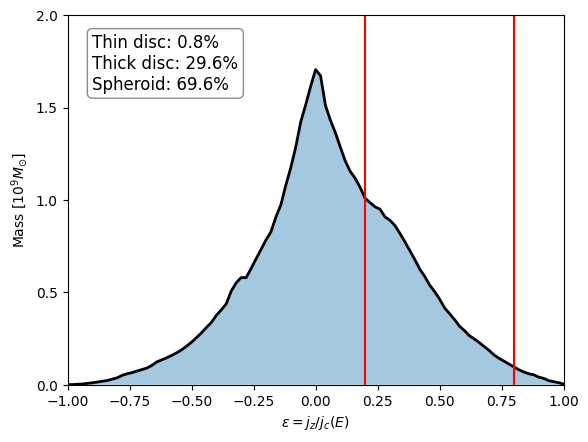

In [209]:
bins = np.linspace(-1, 1, 101)

# histogram (mass weighted)
hist, edges = np.histogram(epsilon, bins=bins, weights=star_m)

# convert to mass fraction density
bin_width = edges[1] - edges[0]
hist = hist / np.sum(star_m)
hist = hist / bin_width

x = edges
y = np.concatenate(([hist[0]], hist))  # match length to edges

# plot smooth line
plt.plot(x, y, color="k", lw=2)

# fill underneath
plt.fill_between(x, y, alpha=0.4)

# vertical cuts
plt.axvline(0.2, c="r")
plt.axvline(0.8, c="r")

plt.xlim(-1, 1)
plt.ylim(0)

plt.xlabel(r"$\epsilon = j_z / j_c(E)$")
plt.ylabel(r"Mass $[10^{9} M_{\odot}]$")

plt.yticks([0, 0.5, 1, 1.5, 2])

# =========================
# COMPUTE FRACTIONS
# =========================

thin_mask = epsilon >= 0.8
thick_mask = (epsilon >= 0.2) & (epsilon < 0.8)
sph_mask = epsilon < 0.2

M_tot = np.sum(star_m)

f_thin = 100 * np.sum(star_m[thin_mask]) / M_tot
f_thick = 100 * np.sum(star_m[thick_mask]) / M_tot
f_sph = 100 * np.sum(star_m[sph_mask]) / M_tot

# =========================
# TEXT STRING (MATCH FIGURE STYLE)
# =========================

textstr = f"Thin disc: {f_thin:.1f}%\nThick disc: {f_thick:.1f}%\nSpheroid: {f_sph:.1f}%"

# =========================
# ADD TEXTBOX TO PLOT
# =========================

plt.text(
    0.05,
    0.95,  # top-left corner (axes coords)
    textstr,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"),
)

plt.show()

snap 214 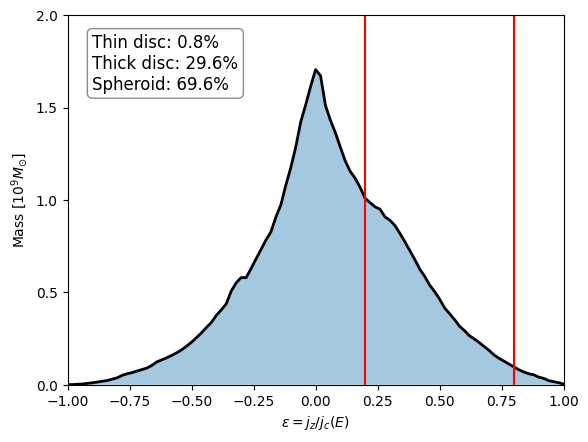

snap 294 
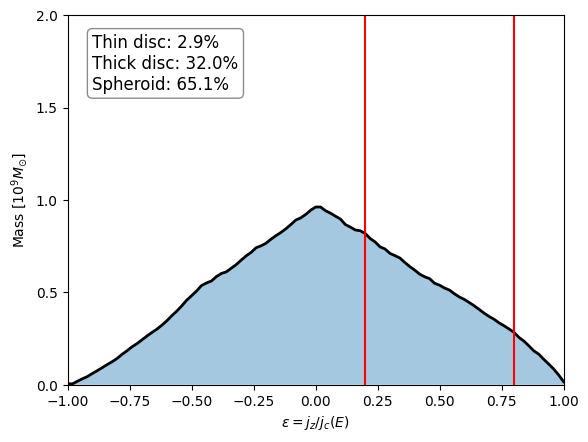

snap 332 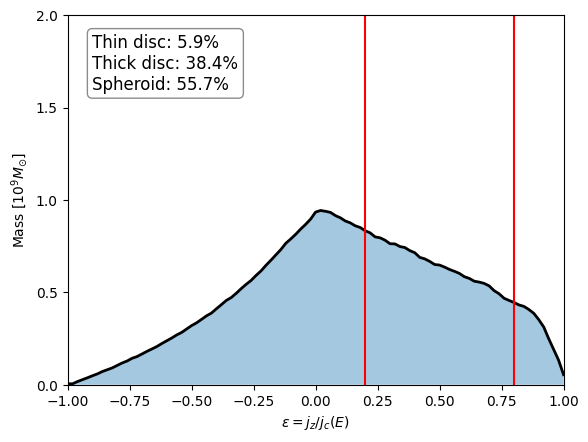

snap 382 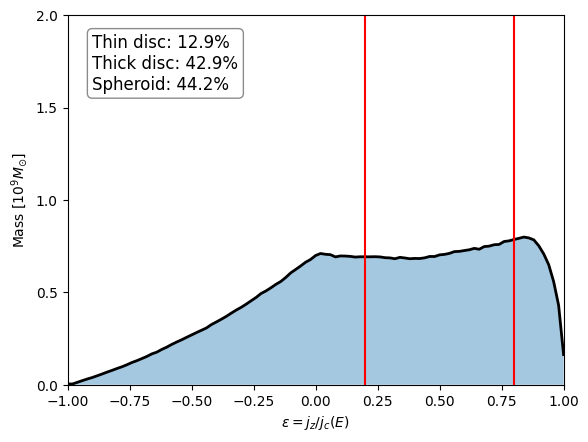

snap 486 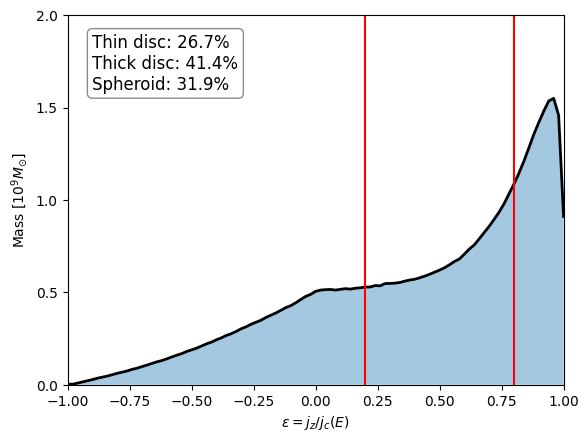